# Quick intro to Python and Jupyter notebooks

## Jupyter notebooks

This is a [Jupyter](https://jupyter.org/) notebook, a modern tool for scientific computing, explorative data analysis and more. The notebook format makes it easy to present calculations and explanations neatly together. It is well worth getting familiar with Jupyter as it is now a standard tool in many sciences. It combines formatted text (Markdown), code and code output in one document consisting of many _cells_. This code can be Python (like here), but Jupyter itself is language-agnostic.

As opposed to Python scripts with the `.py` filename extensions, notebooks have the `.ipynb` extension. I recommend opening and editing notebooks in either [JupyterLab](https://jupyterlab.readthedocs.io/en/latest/) or [Visual Studio Code](https://code.visualstudio.com).


### Editing and running

Choose the type of the current cell using either the GUI (in JupyterLab, the dropdown above; in VS Code, the lower right corner of the cell), or -- more easily -- the appropriate shortcut key: `Y` for code, `M` for Markdown. 

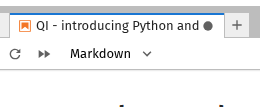
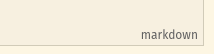

You enter code in cells and run each cell with `Ctrl-Enter` or `Shift-Enter`.

There are two different modes: _Command_ and _Edit_. When you enter text or code in cells, you are in Edit mode. To switch to Command mode, either run the cell or press Esc. When you're in command mode, you can e.g. insert new cells above or below the current with `A` and `B`, copying and pasting cells with `C` and `V`, deleting cells with `D-D`, etc.



## Python

By now, I expect all of you to be at least somewhat familiar with Python and NumPy. This didn't use to be the case, so several years ago I prepared the quick intro below. You are probably familiar with most of the concepts. If not, please spend a little time going through the examples and play around on your own.

In any case, you should as a minimum go through the [Application: qubits](#Application:-qubits) section.

## Let's get started

This intro tutorial just shows you some basic Python functionality and how it can be applied to simple quantum information tasks. Before we get started, if you would like to save any changes you do to this notebook, you need to copy it to your `work` folder. You can do that from the file browser panel: Right click on the notebook file, pick _Copy_, then navigate to `work` and do a right-click _Paste_. If you want to create a new notebook, use the _New launcher_ (plus icon) button on the file browser and choose a Python 3 notebook in the main window.


Now, first we need to import [Numpy](https://www.numpy.org/). Apart from the basic programming language, most functionality in Python is accessed through imports of packages. These can either come from the standard library included in the Python installation (e.g. `math`) or from third parties (e.g. `numpy`). When you do numerical work, you will usually use Numpy, which is the foundation of most scientific Python packages. We rename it `np` as it will be used often. Move through the cells below with `Shift-Enter` to get the outputs.


In [ ]:
import numpy as np

Python has a very useful list data type, but it doesn't work well for linear algebra. For that reason we use arrays from Numpy instead.

In [ ]:
list1 = [0, 1, 2]
list2 = [3, 4, 5]
list1 + list2

In [ ]:
array1 = np.array(list1)
array2 = np.array([3, 4, 5])
array1 + array2

Numpy has many functions for generating one- and multi-dimensional arrays. A few examples:

In [ ]:
np.arange(10)

In [ ]:
np.linspace(0, 1, 11)

In [ ]:
np.zeros((2, 2))

In [ ]:
np.random.random((3, 5))

You can use the `@` operator for matrix/vector multiplication. Very handy for linear algebra:

In [ ]:
matrix1 = np.array([[0, 1], [2, 3]])
matrix1

In [ ]:
vector1 = np.array([1, 10])
vector1

In [ ]:
matrix1 @ vector1, vector1 @ matrix1

Python/Numpy has no concept of "rows" and "columns" as such - you don't need to put the vector on the right side of the matrix in column form. In exchange, you can have arbitrarily many dimensions. Numpy tries to figure out which dimensions fit together and will raise an error if it cannot:

In [ ]:
matrix1 * vector1

Notice how this was different from the matrix multiplication before. Here, the `*` operator works element-wise, similar to `.*` in Matlab (if you're more familiar with that).

In [ ]:
matrix2 = np.ones((2, 4))
matrix2

In [ ]:
matrix2 * vector1

This resulted in an error because the dimensions did not match. Let's try to reshape the vector to match the matrix:

In [ ]:
vector1b = np.reshape(vector1, (2, 1))
vector1b

In [ ]:
matrix2 * vector1b

## Attributes and methods

In Python, everything is an object and every object has attributes (values) and methods (functions) attached to it. These can be accessed by a period after the variable name. These come in handy all the time.

> **Hint**: A super useful trick in JupyterLab is to press `Tab` after entering the period. This will bring up a list of all existing methods and attributes of the object. In VS Code, it should appear automatically (but may depend on your settings).

As an example, a complex number has the attribute `imag` (the imaginary part) and the method `conjugate`. Methods are functions, and as such require parentheses afterwards (this particular method has no arguments, so the parentheses are empty). 

In [ ]:
a = 5 + 2j  # note that complex numbers use 'j' instead of 'i'
a.imag

In [ ]:
a.conjugate()

Numpy arrays are significantly richer structures with a large number of attributes and methods. Some examples:

In [ ]:
matrix1.shape  # the array's dimensions

In [ ]:
matrix1.flatten()  # collapse to 1-D

In [ ]:
matrix1.trace()  # matrix trace

In [ ]:
matrix1.T  # transpose

In [ ]:
matrix1.sum(axis=0)  # sum along the first dimension (indexing starts at 0)

In [ ]:
matrix1.sum(axis=1)  # sum along the second dimension

In [ ]:
matrix1.sum()  # sum all

## Application: qubits

Now, let's get straight to quantum information and start by defining the qubit basis states $|0\rangle, |1\rangle$ and Pauli operators $\hat{I}, \hat{\sigma}_x, \hat{\sigma}_y, \hat{\sigma}_z$.

In [ ]:
ket0 = np.array([1, 0])
ket1 = np.array([0, 1])

I = np.array([[1, 0], [0, 1]])
sigmax = np.array([[0, 1], [1, 0]])
sigmay = np.array([[0, -1j], [1j, 0]])
sigmaz = np.array([[1, 0], [0, -1]])

Operating with $\hat{\sigma}_x$ on the $|0\rangle$ state transforms it into $|1\rangle$:

In [ ]:
sigmax @ ket0

If we want to rotate by an arbitrary amount $\theta$ around e.g. the x-axis of the Bloch sphere, we need the unitary operator $\hat{U}_x(\theta) = \exp\left(i \frac{\theta}{2} \hat{\sigma}_x\right)$ (see p.47 in Barnett). To do the exponential of a matrix, we need to import the [`expm` function](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.linalg.expm.html) from the linalg package in [Scipy](https://www.scipy.org/), an important collection of scientific functions and tools.

Let's try to do a $\pi/2$ rotation around x, $|\phi\rangle = \hat{U}_x(\pi/2) |0\rangle$.

In [ ]:
from scipy.linalg import expm

phi = expm(1j * 0.5 * np.pi / 2 * sigmax) @ ket0
phi

This is the +1 eigenstate of $\hat{\sigma}_y$ as it should be. We can check in two ways:

In [ ]:
sigmay @ phi

In [ ]:
np.isclose(phi, 1/np.sqrt(2) * (ket0 + 1j * ket1))

Now, if we get interested in working with density operators instead of just bras and kets, we need to do the outer product $|\psi\rangle\langle\psi|$ of the state vectors. For convenience, let's define a function that does that for us. (The part inside triple quotes is documentation - this is optional. You can see function documentation in JupyterLab by pressing Shift-Tab once or twice with the cursor placed inside the parentheses following a function name, and in VS Code by hovering the mouse above the function name.)

In [ ]:
def ket2dm(ket):
    """Transforms ket to density operator.
    
    Parameters
    ==========
    
    ket : input ket
    """
    bra = np.conj(ket)
    dm = np.outer(ket, bra)
    return dm

In [ ]:
ket2dm(ket0)

In [ ]:
ket2dm(phi)

What is the expectation value for a measurement of $\hat{\sigma}_z$ for each of those two states, $|0\rangle$ and $|\phi\rangle$? Think now before you continue.

The expectation value is given by $\langle \hat{\sigma}_z \rangle = \mathrm{Tr}(\hat{\rho} \hat{\sigma}_z)$. In Numpy, the matrix trace can be implemented either by the function `np.trace(rho)` or by applying the `trace` method of an array object. Let's try the second approach for demonstration purpose.

In [ ]:
(ket2dm(ket0) @ sigmaz).trace()

In [ ]:
(ket2dm(phi) @ sigmaz).trace()

Note that this last output is 0 within numerical precision.

Are these the values you expected? Good.

What about a mixed state $\frac{1}{2}(|0\rangle\langle0| + |1\rangle\langle1|)$ rather than the corresponding superposition state $|\phi\rangle$? And when measuring $\hat{\sigma}_y$ instead?

In [ ]:
(1/2 * (ket2dm(ket0) + ket2dm(ket1)) @ sigmaz).trace()

In [ ]:
(1/2 * (ket2dm(ket0) + ket2dm(ket1)) @ sigmay).trace()

As expected.

## Plotting

The standard package for plotting data in Python is [Matplotlib](https://matplotlib.org/). It includes the _pyplot_ interface which is supposed to make it work very similarly to Matlab. Alternatively, there's also a more "pythonic" object-oriented interface to the plotting library. Below is just a quick illustration of the _pyplot_ interface. To learn more, check the [tutorials](https://matplotlib.org/tutorials/index.html) and [gallery](https://matplotlib.org/gallery/index.html).

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
t = np.linspace(0, 10, 400)
envelope = np.exp(-t**2 / 5**2)
wave = np.cos(t**2) * envelope

plt.plot(t, wave)
plt.plot(t, envelope, '--')
plt.grid()
plt.xlabel('t')
plt.ylabel('amplitude')
plt.legend(['wave', 'envelope'])

## Further reading

Now, feel free to play around and get familiar with Jupyter, Python/Numpy and with doing quantum mechanics (or just linear algebra?) in this setting.

You may be quite confused with what was presented above - especially if you have no prior Python experience. I urge you to simply play around and see what happens. Don't be afraid - nothing should break :)

For a more thorough overview of the Numpy array structure, I recommend reading the [quickstart guide](https://docs.scipy.org/doc/numpy/user/quickstart.html). It is also super useful to get familiar with the many fancy ways of [indexing arrays](https://docs.scipy.org/doc/numpy/user/basics.indexing.html). If the examples above on how "dimensions fit together" were puzzling, have a look at [Numpy's broadcasting rules](https://docs.scipy.org/doc/numpy/user/basics.broadcasting.html).

Finally, I highly recommend the [_Scientific Python_ notebook lectures](https://github.com/jrjohansson/scientific-python-lectures) by J. Robert Johansson, in particular lectures 0 to 4. To easily get started with them, they are included here in the shared folder. They are slightly dated, but most things are still relevant (for example, Jupyter was still called IPython at the time of writing and the `@` operator didn't exist). In some places you will not be able to run the notebooks without getting errors (e.g. because they use Python 2 syntax for `print` statements), so it may be better to just read along and try out examples in a separate notebook.